In [1]:
import pandas as pd
import numpy as np
import keras
import sklearn
import os
import glob
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import time
from PIL import Image
from tensorflow import keras
from sklearn.utils import resample
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, AdamW, Nadam, Adamax, RMSprop, SGD, Lion
from tqdm import tqdm

In [2]:
#Load the dataframe
skin_df = pd.read_csv('C:/Users/rosny/OneDrive/Documents/Computer_Engineering_M2/Thesis/Skin_cancer_dataset/data/HAM10000/HAM10000_metadata.csv')
le = LabelEncoder().fit(skin_df['dx'])
print(list(le.classes_))

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [3]:
#We define the batch size, image width and height
BATCH_SIZE = 32
img_height = 128
img_width = 128

#Our dictionnary
dict = {
    'akiec': 0,
    'bcc': 1, 
    'bkl': 2,
    'df': 3, 
    'mel': 4,
    'nv': 5,
    'vasc' : 6,
}

In [4]:
#Checking the dataframe

skin_df['label'] = le.transform(skin_df["dx"])
print(skin_df.sample(10))

        lesion_id      image_id    dx    dx_type   age     sex  \
2767  HAM_0005536  ISIC_0026798   bcc      histo  45.0    male   
1094  HAM_0001223  ISIC_0030789   bkl  consensus  75.0    male   
9325  HAM_0007484  ISIC_0031750    nv  consensus  15.0  female   
7073  HAM_0007138  ISIC_0031501    nv      histo  25.0    male   
2384  HAM_0005471  ISIC_0028146  vasc      histo  60.0  female   
1788  HAM_0006802  ISIC_0033279   mel      histo  40.0    male   
2067  HAM_0000952  ISIC_0026009   mel      histo  80.0  female   
9103  HAM_0000976  ISIC_0031880    nv      histo  40.0    male   
4280  HAM_0003490  ISIC_0031162    nv  follow_up  50.0    male   
5193  HAM_0001899  ISIC_0031549    nv  follow_up  45.0  female   

         localization  label  
2767  lower extremity      1  
1094            trunk      2  
9325  lower extremity      5  
7073             hand      5  
2384             back      6  
1788  upper extremity      4  
2067  lower extremity      4  
9103            chest    

In [5]:
#We create the path for reading all the images

image_path = {os.path.splitext(os.path.basename(x)) [0] : x
             for x in glob.glob(os.path.join('C:/Users/rosny/OneDrive/Documents/Computer_Engineering_M2/Thesis/Skin_cancer_dataset/data/HAM10000/', '*', '*.jpg'))}

In [6]:
#Read the image using the path

skin_df['path'] = skin_df['image_id'].map(image_path.get)
skin_df['image'] = skin_df['path'].map(lambda x : np.asarray(Image.open(x).resize((img_height, img_width))))

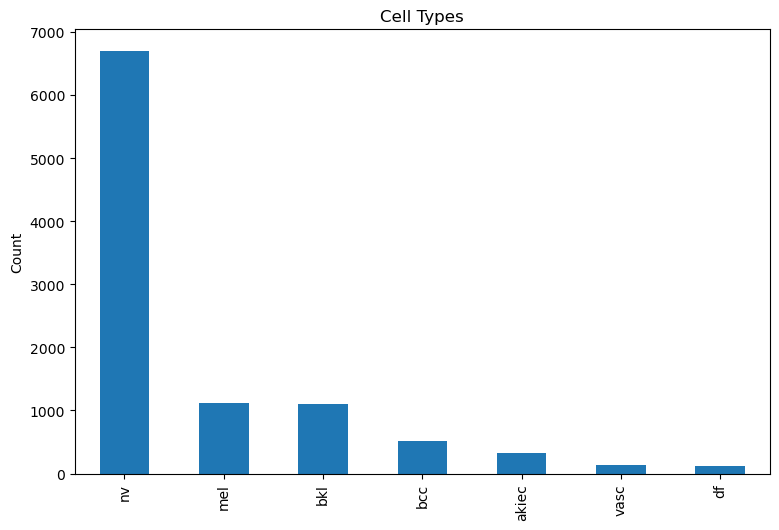

In [7]:
#Data distribution visualisation

fig = plt.figure(figsize=(15,10))
ax1 = fig.add_subplot(221)
skin_df['dx'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count')
ax1.set_title('Cell Types')

plt.tight_layout()
plt.show()

In [8]:
#Look our differents classe

print(skin_df['label'].value_counts())

5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: label, dtype: int64


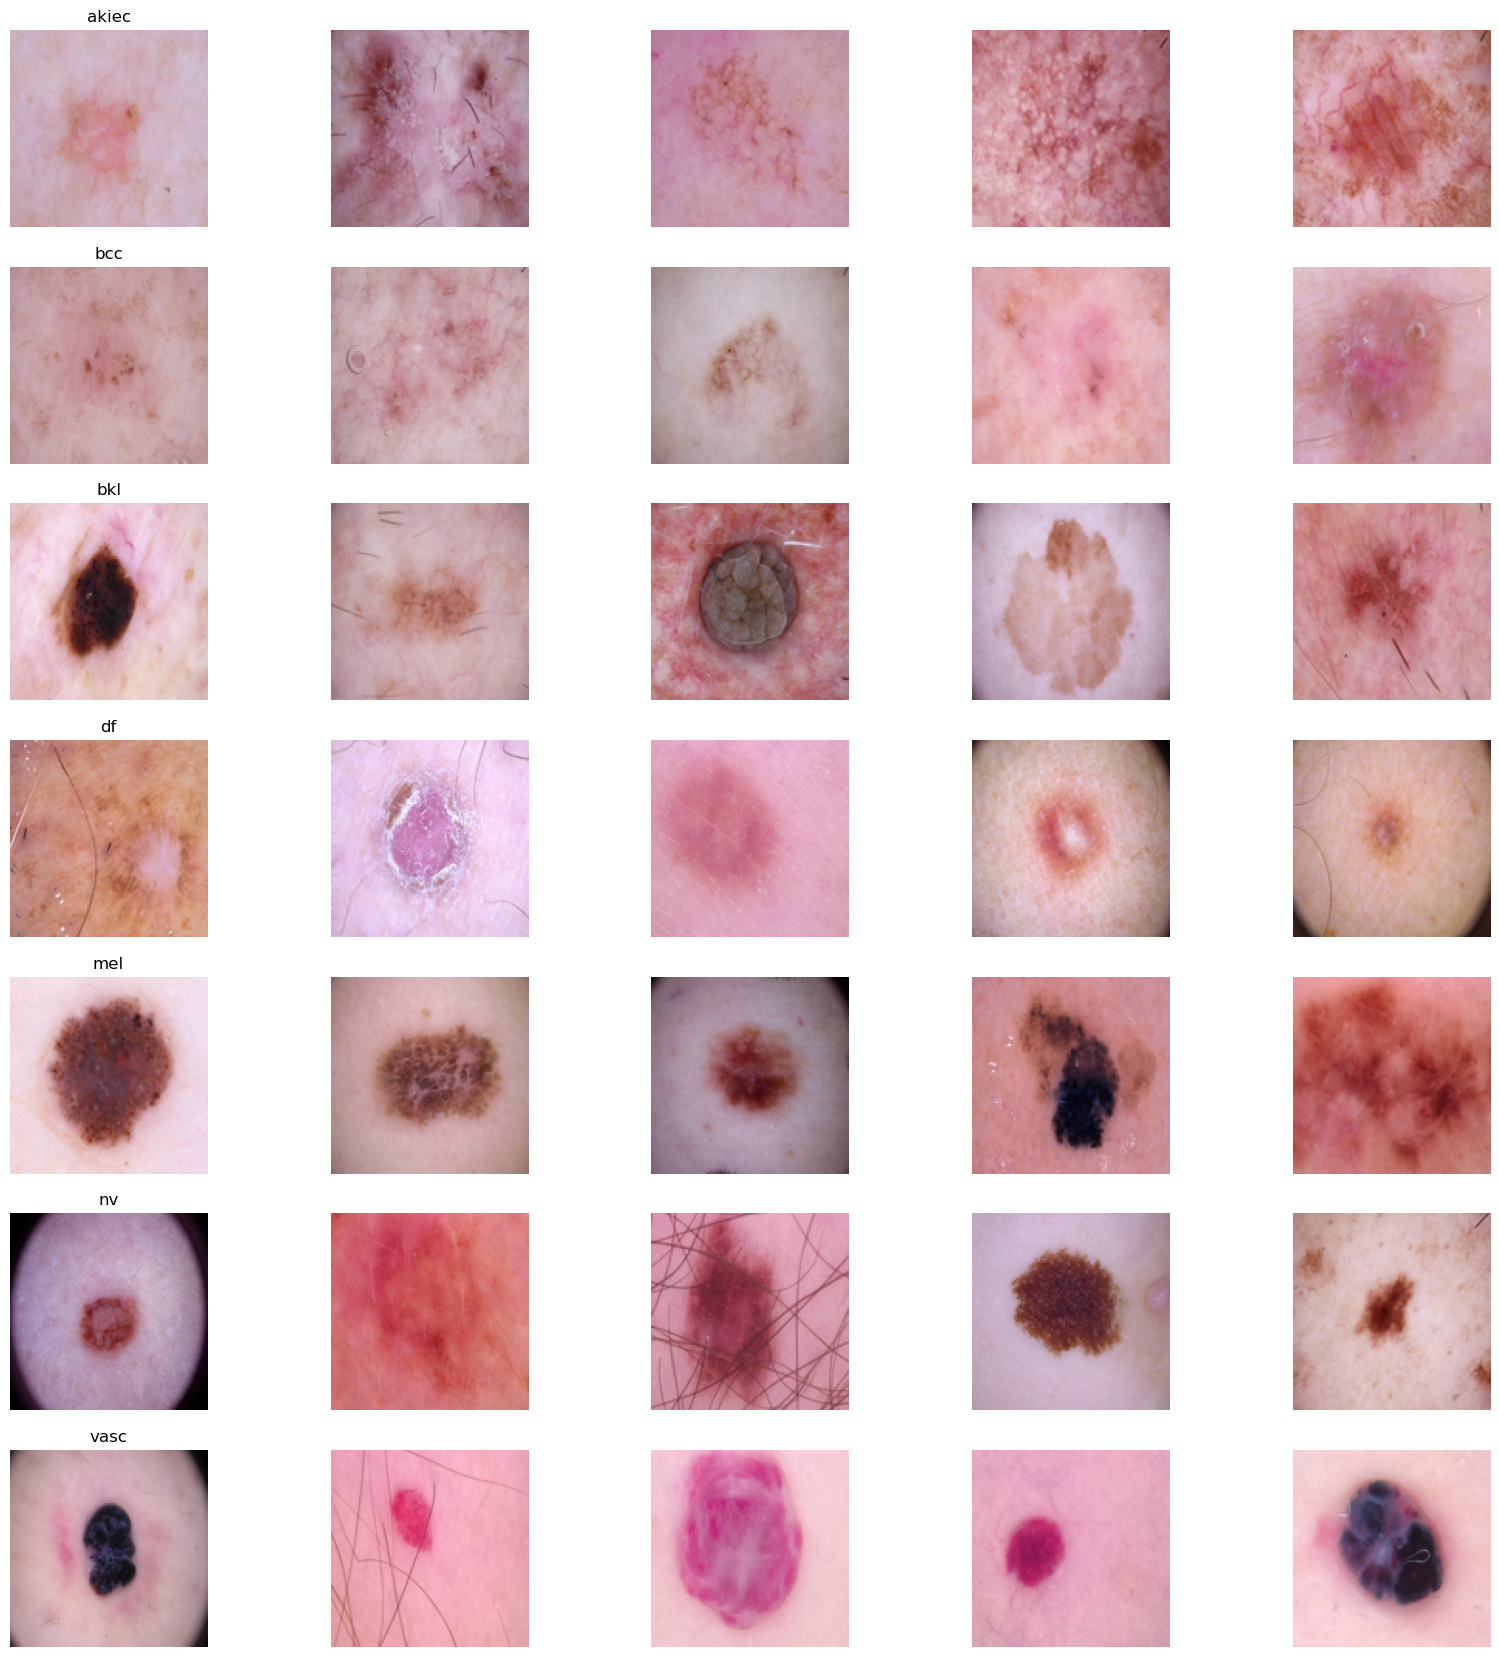

In [9]:
#Show the images

np_samples = 5
fig, m_axes = plt.subplots(7, np_samples, figsize=(4*np_samples, 3*7))
for n_axes, (type_name, type_rows) in zip(m_axes, skin_df.sort_values(['dx']).groupby('dx')):
    
    n_axes[0].set_title(type_name) 
    for c_axes, (_, c_rows) in zip(n_axes, type_rows.sample(np_samples, random_state=1234).iterrows()):
                                                                 c_axes.imshow(c_rows['image'])
                                                                 c_axes.axis('off')

In [10]:
#Define the classes to augment and the class to exclude
classes_to_augment = ['akiec', 'bcc','bkl', 'df', 'mel', 'vasc']  
class_to_exclude = 'nv'

In [11]:
#Data augmentation with ImageDataGenerator
augmented_data_gen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'

)

In [12]:
#Filter the dataframe for classes to augment
augmentation_df = skin_df[skin_df['dx'].isin(classes_to_augment)]

In [13]:
#Filter out the class to exclude
augmentation_df = augmentation_df[augmentation_df['dx'] != class_to_exclude]

In [14]:
#Shuffle the dataframe
augmentation_df = shuffle(augmentation_df)

In [15]:
# Create an empty list to store augmented samples
augmented_samples = []

# Set the total number of images to generate for each class
total_images_per_class = 6000  

# Set the batch size for processing
batch_size = BATCH_SIZE

for target_class in classes_to_augment:
    # Filter the dataframe for the current class
    class_df = augmentation_df[augmentation_df['dx'] == target_class]
    
    # Calculate the number of images to generate for this class
    remaining_images = total_images_per_class - len(class_df)
    print(f"Class: {target_class}")
    print(f"Original Count: {len(class_df)}, To Generate: {remaining_images}")
    
    # Generate augmented images until the target count is reached
    generated_count = 0
    while generated_count < remaining_images:
        # Randomly select an image from the class DataFrame
        img_index = np.random.randint(0, len(class_df))
        img = np.expand_dims(class_df.iloc[img_index]['image'], axis=0)
        
        # Generate augmented images for this batch
        augmented_img = next(augmented_data_gen.flow(img, batch_size=1))[0]
        
        # Store the augmented image
        augmented_samples.append({
            'image_id': class_df.iloc[img_index]['image_id'],
            'dx': class_df.iloc[img_index]['dx'],
            'image': augmented_img
        })
        generated_count += 1
    
    print(f"Generated {generated_count} augmented images for class {target_class}.")


Class: akiec
Original Count: 327, To Generate: 5673
Generated 5673 augmented images for class akiec.
Class: bcc
Original Count: 514, To Generate: 5486
Generated 5486 augmented images for class bcc.
Class: bkl
Original Count: 1099, To Generate: 4901
Generated 4901 augmented images for class bkl.
Class: df
Original Count: 115, To Generate: 5885
Generated 5885 augmented images for class df.
Class: mel
Original Count: 1113, To Generate: 4887
Generated 4887 augmented images for class mel.
Class: vasc
Original Count: 142, To Generate: 5858
Generated 5858 augmented images for class vasc.


In [16]:
#Create a DataFrame from augmented samples
augmented_df = pd.DataFrame(augmented_samples)

In [17]:
#Combine original and augmented data
combined_df = pd.concat([augmentation_df, augmented_df], ignore_index=True)
print(f"Total images after combining: {len(combined_df)}")

Total images after combining: 36000


In [18]:
#Verify the total of image in each class

class_counts = combined_df['dx'].value_counts()
print("Image count per class:")
print(class_counts)

Image count per class:
bcc      6000
bkl      6000
mel      6000
akiec    6000
df       6000
vasc     6000
Name: dx, dtype: int64


In [19]:
#Create a DataFrame from augmented samples and original images
combined_new_df = pd.DataFrame(combined_df)

In [20]:
#Excluded class
except_class_df = skin_df[skin_df['dx'] == class_to_exclude]

#Number of images to sample
num_samples = 6000

#Sample the desired number of images
sampled_excluded_class_df = except_class_df.sample(n=num_samples, random_state=42)

print(f"Sampled {len(sampled_excluded_class_df)} images from the excluded class.")

Sampled 6000 images from the excluded class.


In [21]:
#Concatenate augmented DataFrame with the exception class DataFrame
final_combined_df = pd.concat([combined_new_df, sampled_excluded_class_df], ignore_index=True)

In [22]:
#Check the new Dataframe
print(final_combined_df.shape)

(42000, 10)


In [23]:
# Count images per class
class_counts = final_combined_df['dx'].value_counts()
print("Final image count per class:")
print(class_counts)

Final image count per class:
bcc      6000
bkl      6000
mel      6000
akiec    6000
df       6000
vasc     6000
nv       6000
Name: dx, dtype: int64


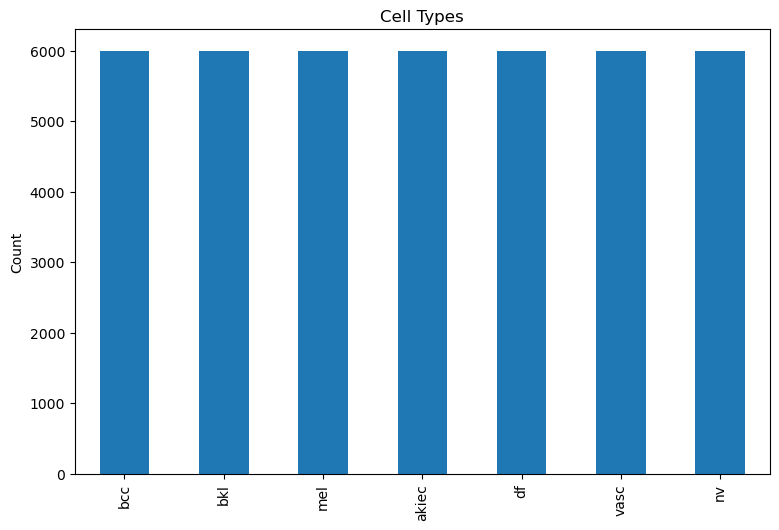

In [24]:
#Data distribution visualisation after data augmentation

fig = plt.figure(figsize=(15,10))
ax1 = fig.add_subplot(221)
final_combined_df['dx'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count')
ax1.set_title('Cell Types')

plt.tight_layout()
plt.show()

In [25]:
#Check the count of each label
label_counts = final_combined_df['dx'].value_counts()
print(label_counts)

bcc      6000
bkl      6000
mel      6000
akiec    6000
df       6000
vasc     6000
nv       6000
Name: dx, dtype: int64


In [26]:
#Initialize LabelEncoder
label_encoder = LabelEncoder()

#Fit and transform the 'dx' column to numerical labels
final_combined_df['label'] = label_encoder.fit_transform(final_combined_df['dx'])

In [27]:
#Convert dataframe column of images into numpy array

X = np.array(final_combined_df['image'].tolist())
X = X/255.
Y = final_combined_df['label']
Y_cat = to_categorical(Y, num_classes = 7)

In [28]:
#Split our dataframe into train and test

train_data, X_test, train_labels, Y_test = train_test_split(X, Y_cat, test_size=0.2, random_state=42)

In [29]:
#Show our training and testing set

print(train_data.shape, train_labels.shape)
print(X_test.shape, Y_test.shape)

(33600, 128, 128, 3) (33600, 7)
(8400, 128, 128, 3) (8400, 7)


In [30]:
#Split into validation
train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size=0.10, random_state=42)

In [31]:
#Show our training, testing and validation set

print(train_data.shape, train_labels.shape)
print(X_test.shape, Y_test.shape)
print(val_data.shape, val_labels.shape)

(30240, 128, 128, 3) (30240, 7)
(8400, 128, 128, 3) (8400, 7)
(3360, 128, 128, 3) (3360, 7)


In [32]:
#Model_3
#CNN model

model = Sequential()

# Input Layer
model.add(tf.keras.layers.Input(shape=(img_height, img_width, 3)))

#First Conv Block
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(tf.keras.layers.BatchNormalization()) 
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(tf.keras.layers.BatchNormalization()) 
model.add(tf.keras.layers.MaxPooling2D())

#Second Conv Block
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal'))
model.add(tf.keras.layers.BatchNormalization()) 
model.add(tf.keras.layers.MaxPooling2D())

#Third Conv Block
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

#Fourth Conv Block
model.add(tf.keras.layers.Conv2D(256, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(256, (3, 3), activation="swish", padding='same', kernel_initializer='he_normal'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())



#Global Average Pooling
model.add(GlobalAveragePooling2D())

#Fully Connected Block
model.add(tf.keras.layers.Dense(512, activation="swish", kernel_initializer='he_normal', kernel_regularizer=keras.regularizers.L1L2()))
model.add(tf.keras.layers.Dropout(0.4))

# Output Layer
model.add(tf.keras.layers.Dense(7, activation='softmax', kernel_initializer='glorot_uniform', name='classifier'))

In [33]:
#Learning rate scheduler
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

In [34]:
from tensorflow.keras.utils import plot_model

In [35]:
#Plot the model 
plot_model(model, to_file='cnn_archotecture.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [36]:
#Compile the model

optimizer = tf.optimizers.Adam(learning_rate=1e-4, weight_decay=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [37]:
#Callbacks for early stopping and saving best model
#Early stopping with lower patience

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')

In [38]:
#Define the learning rate scheduler callback
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

In [39]:
#The summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             

 Total params: 1,311,271 (5.00 MB)

 Trainable params: 1,309,351 (4.99 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [40]:
#Start timer for the train
start_train_time = time.time()

In [ ]:
#We train our model
history = model.fit(train_data, train_labels, BATCH_SIZE,
         callbacks=[model_checkpoint, lr_scheduler],           
         validation_data=(val_data, val_labels),
         epochs=50)

Epoch 1/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4826 - loss: 1.5187

945/945 ━━━━━━━━━━━━━━━━━━━━ 1473s 2s/step - accuracy: 0.4827 - loss: 1.5184 - val_accuracy: 0.6637 - val_loss: 0.9905 - learning_rate: 1.0000e-04
Epoch 2/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6626 - loss: 1.0215

945/945 ━━━━━━━━━━━━━━━━━━━━ 1453s 2s/step - accuracy: 0.6626 - loss: 1.0215 - val_accuracy: 0.7176 - val_loss: 0.8475 - learning_rate: 1.0000e-04
Epoch 3/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7212 - loss: 0.8580

945/945 ━━━━━━━━━━━━━━━━━━━━ 1447s 2s/step - accuracy: 0.7212 - loss: 0.8580 - val_accuracy: 0.7738 - val_loss: 0.7259 - learning_rate: 1.0000e-04
Epoch 4/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7723 - loss: 0.7366

945/945 ━━━━━━━━━━━━━━━━━━━━ 1412s 1s/step - accuracy: 0.7723 - loss: 0.7366 - val_accuracy: 0.8057 - val_loss: 0.6461 - learning_rate: 1.0000e-04
Epoch 5/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7914 - loss: 0.6681

...

945/945 ━━━━━━━━━━━━━━━━━━━━ 1393s 1s/step - accuracy: 0.9119 - loss: 0.3557 - val_accuracy: 0.8836 - val_loss: 0.4268 - learning_rate: 1.0000e-04
Epoch 12/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1392s 1s/step - accuracy: 0.9250 - loss: 0.3166 - val_accuracy: 0.8628 - val_loss: 0.4947 - learning_rate: 1.0000e-04
Epoch 13/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1399s 1s/step - accuracy: 0.9341 - loss: 0.2957 - val_accuracy: 0.8863 - val_loss: 0.4458 - learning_rate: 1.0000e-04
Epoch 14/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9461 - loss: 0.2639

945/945 ━━━━━━━━━━━━━━━━━━━━ 1382s 1s/step - accuracy: 0.9461 - loss: 0.2639 - val_accuracy: 0.9065 - val_loss: 0.3911 - learning_rate: 1.0000e-04
Epoch 15/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1364s 1s/step - accuracy: 0.9567 - loss: 0.2398 - val_accuracy: 0.8952 - val_loss: 0.4057 - learning_rate: 1.0000e-04
Epoch 16/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1376s 1s/step - accuracy: 0.9628 - loss: 0.2201 - val_accuracy: 0.8863 - val_loss: 0.4779 - learning_rate: 1.0000e-04
Epoch 17/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1387s 1s/step - accuracy: 0.9697 - loss: 0.2011 - val_accuracy: 0.8905 - val_loss: 0.4575 - learning_rate: 1.0000e-04
Epoch 18/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9818 - loss: 0.1679

945/945 ━━━━━━━━━━━━━━━━━━━━ 1386s 1s/step - accuracy: 0.9818 - loss: 0.1679 - val_accuracy: 0.9122 - val_loss: 0.3814 - learning_rate: 5.0000e-05
Epoch 19/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1386s 1s/step - accuracy: 0.9881 - loss: 0.1485 - val_accuracy: 0.8836 - val_loss: 0.5206 - learning_rate: 5.0000e-05
Epoch 20/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1387s 1s/step - accuracy: 0.9903 - loss: 0.1428 - val_accuracy: 0.9080 - val_loss: 0.4187 - learning_rate: 5.0000e-05
Epoch 21/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1388s 1s/step - accuracy: 0.9890 - loss: 0.1409 - val_accuracy: 0.9060 - val_loss: 0.4345 - learning_rate: 5.0000e-05
Epoch 22/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1381s 1s/step - accuracy: 0.9956 - loss: 0.1255 - val_accuracy: 0.9134 - val_loss: 0.4015 - learning_rate: 2.5000e-05
Epoch 23/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9956 - loss: 0.1229

945/945 ━━━━━━━━━━━━━━━━━━━━ 1399s 1s/step - accuracy: 0.9956 - loss: 0.1229 - val_accuracy: 0.9202 - val_loss: 0.3736 - learning_rate: 2.5000e-05
Epoch 24/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1404s 1s/step - accuracy: 0.9964 - loss: 0.1217 - val_accuracy: 0.9262 - val_loss: 0.3806 - learning_rate: 2.5000e-05
Epoch 25/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9969 - loss: 0.1188

945/945 ━━━━━━━━━━━━━━━━━━━━ 1394s 1s/step - accuracy: 0.9969 - loss: 0.1188 - val_accuracy: 0.9238 - val_loss: 0.3707 - learning_rate: 2.5000e-05
Epoch 26/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1391s 1s/step - accuracy: 0.9972 - loss: 0.1181 - val_accuracy: 0.9155 - val_loss: 0.3993 - learning_rate: 2.5000e-05
Epoch 27/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1377s 1s/step - accuracy: 0.9962 - loss: 0.1188 - val_accuracy: 0.9244 - val_loss: 0.3861 - learning_rate: 2.5000e-05
Epoch 28/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1366s 1s/step - accuracy: 0.9966 - loss: 0.1163 - val_accuracy: 0.9226 - val_loss: 0.3942 - learning_rate: 2.5000e-05
Epoch 29/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1366s 1s/step - accuracy: 0.9981 - loss: 0.1125 - val_accuracy: 0.9226 - val_loss: 0.3874 - learning_rate: 1.2500e-05
Epoch 30/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1372s 1s/step - accuracy: 0.9980 - loss: 0.1113 - val_accuracy: 0.9244 - val_loss: 0.3994 - learning_rate: 1.2500e-05
Epoch 31/50
945/945 ━━━━━━━━━━━━━━━━━━━━ 1366s 1s/step - a

In [62]:
#End timer
end_train_time = time.time()

#Calculate and display training time
training_time = end_train_time - start_train_time
print(f"Training time: {training_time:.2f} seconds")

Training time: 70027.16 seconds


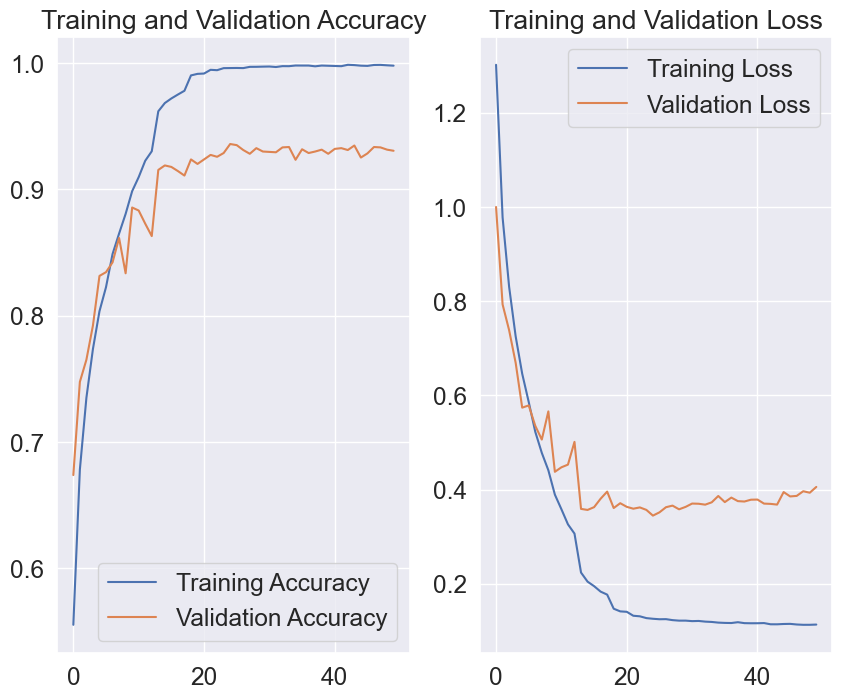

In [63]:
#Display the graph of the training and validation

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(50)
plt.figure(figsize = (10, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label = 'Training Accuracy')
plt.plot(epochs_range, val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = 'Training Loss')
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

In [64]:
#Start timer for the testing
start_test_time = time.time()

In [65]:
#Model evaluation

score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.4011312425136566
Test accuracy: 0.9284523725509644


In [66]:
#End timer
end_test_time = time.time()

# Calculate and display testing time
testing_time = end_test_time - start_test_time
print(f"Testing time: {testing_time:.2f} seconds")

Testing time: 100.35 seconds


In [67]:
y_pred = model.predict(X_test, steps = len(X_test), verbose=1)

8400/8400 ━━━━━━━━━━━━━━━━━━━━ 166s 20ms/step


In [68]:
y_pred_classes = np.argmax(y_pred, axis=1)

In [69]:
y_true = np.argmax(Y_test, axis=1)

Text(83.25, 0.5, 'True Label')

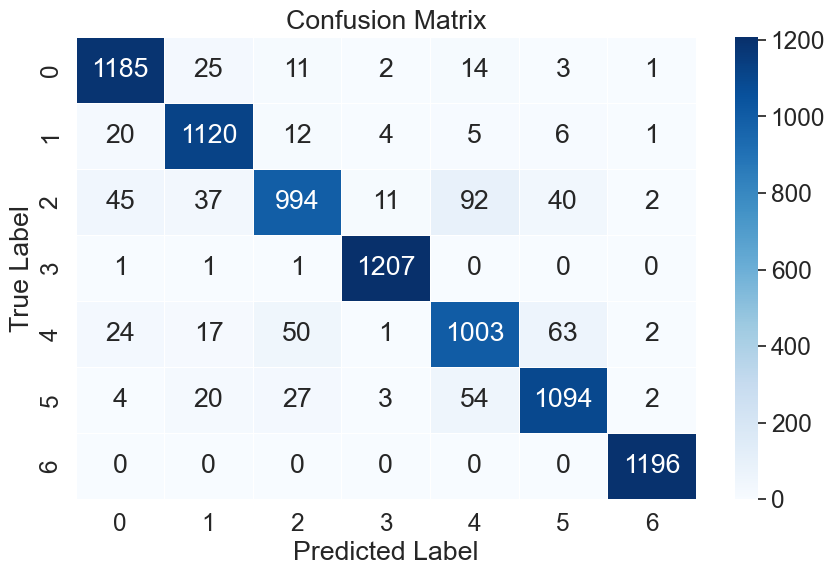

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Confusion matrix
cm=confusion_matrix(y_true, y_pred_classes)

fig, ax=plt.subplots(figsize=(10,6))
sns.set(font_scale=1.6)
sns.heatmap(cm, annot=True, cmap="Blues", linewidths=.5, fmt='d', ax=ax)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1241
           1       0.92      0.96      0.94      1168
           2       0.91      0.81      0.86      1221
           3       0.98      1.00      0.99      1210
           4       0.86      0.86      0.86      1160
           5       0.91      0.91      0.91      1204
           6       0.99      1.00      1.00      1196

    accuracy                           0.93      8400
   macro avg       0.93      0.93      0.93      8400
weighted avg       0.93      0.93      0.93      8400

